In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Concatenation.xlsx to Concatenation (1).xlsx


In [ ]:
df = pd.read_excel("Concatenation.xlsx", sheet_name="Sheet1")

In [ ]:
df.head()

,Station,Bus arrival time,Opening the doors,Closing the doors,Number of entries,Number of exits,Bus movement,position,Date,Time
0,خاوران,06:40:14,06:40:18,06:41:55,22,0,06:41:58,جنوب به شمال,شنبه,صبح
1,بسیج,06:46:17,06:46:30,06:46:43,13,0,06:46:43,جنوب به شمال,شنبه,صبح
2,رحمانی,06:47:09,06:47:16,06:47:25,12,0,06:47:29,جنوب به شمال,شنبه,صبح
3,ولیعصر,06:48:47,06:48:49,06:49:10,1,1,06:49:12,جنوب به شمال,شنبه,صبح
4,رحمانی,07:09:33,07:09:38,07:09:48,7,4,07:09:55,جنوب به شمال,شنبه,صبح


**Number of entries**

In [ ]:
entries = df["Number of entries"].dropna()

In [ ]:
print(entries)

0      22
1      13
2      12
3       1
4       7
       ..
316     2
317     2
318     1
319     1
320     1
Name: Number of entries, Length: 321, dtype: int64


**POISSON**

In [ ]:
mean = entries.mean()
variance = entries.var()
std_dev = entries.std()

print(f"mean: {mean:.2f}")
print(f"Variance: {variance:.2f}")
print(f"Standard deviation: {std_dev:.2f}")

mean: 8.06
Variance: 131.58
Standard deviation: 11.47


In [ ]:
frequency = entries.value_counts().sort_index()

In [ ]:
x_vals = np.arange(frequency.index.min(), frequency.index.max() + 1)
poisson_probs = poisson.pmf(x_vals, mu=mean) * len(entries)

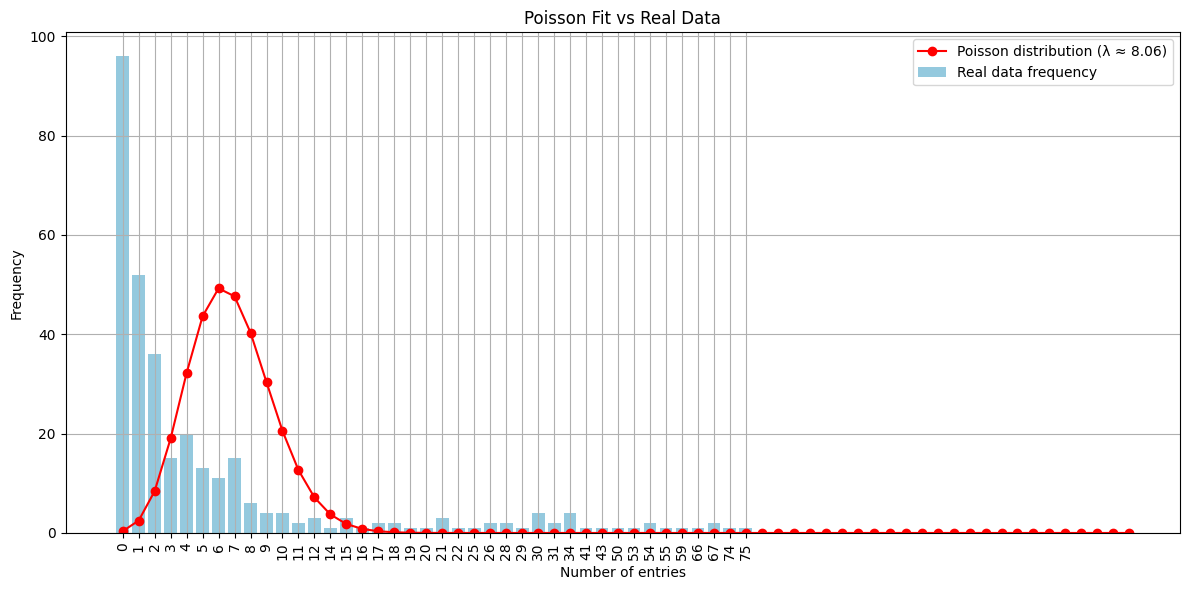

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=frequency.index, y=frequency.values, color="skyblue", label="Real data frequency")
plt.plot(x_vals, poisson_probs, 'r-o', label=f"Poisson distribution (λ ≈ {mean:.2f})")
plt.xlabel("Number of entries")
plt.ylabel("Frequency")
plt.title("Poisson Fit vs Real Data")
plt.legend()
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import nbinom

In [ ]:
p = mean / variance
r = mean**2 / (variance - mean)

In [ ]:
nb_probs = nbinom.pmf(x_vals, r, p) * len(entries)

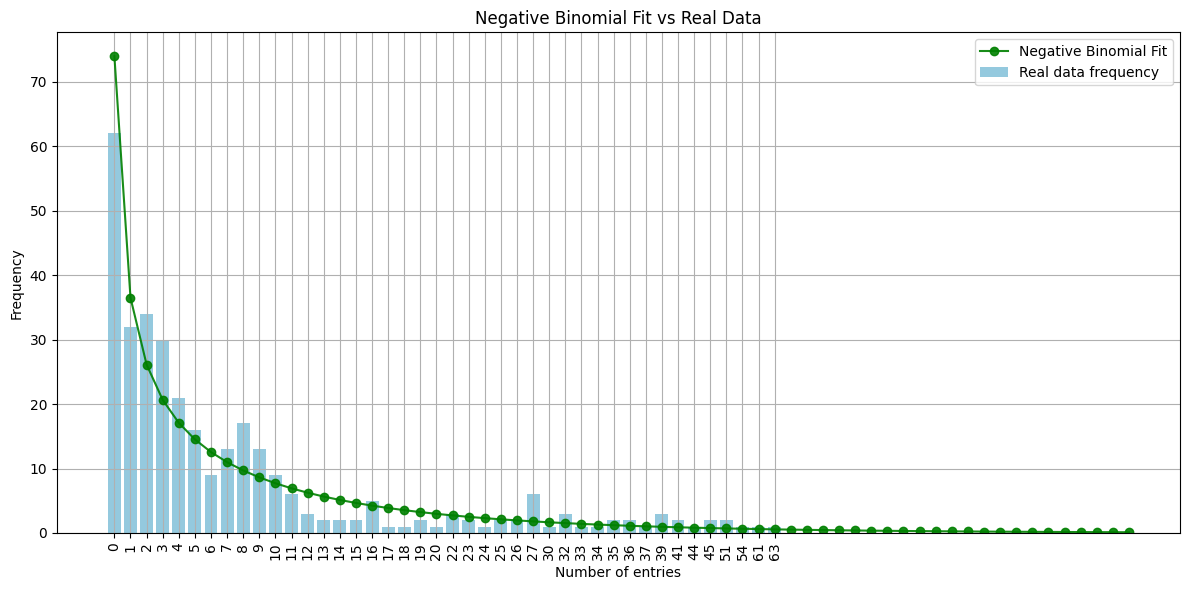

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=frequency.index, y=frequency.values, color="skyblue", label="Real data frequency")
plt.plot(x_vals, nb_probs, 'g-o', label="Negative Binomial Fit", alpha=0.9)
plt.xlabel("Number of entries")
plt.ylabel("Frequency")
plt.title("Negative Binomial Fit vs Real Data")
plt.legend()
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Number of exit**

In [ ]:
exits = df["Number of exits"].dropna()

In [ ]:
exits_mean = exits.mean()
exits_variance = exits.var()
exits_std_dev = exits.std()
print(f"mean: {exits_mean:.2f}")
print(f"Variance: {exits_variance:.2f}")
print(f"Standard deviation: {exits_std_dev:.2f}")

mean: 6.77
Variance: 169.47
Standard deviation: 13.02


In [ ]:
exits_frequency = exits.value_counts().sort_index()

In [ ]:
x_vals_1 = np.arange(exits_frequency.index.min(), exits_frequency.index.max() + 1)
poisson_probs = poisson.pmf(x_vals, mu=exits_mean) * len(exits)

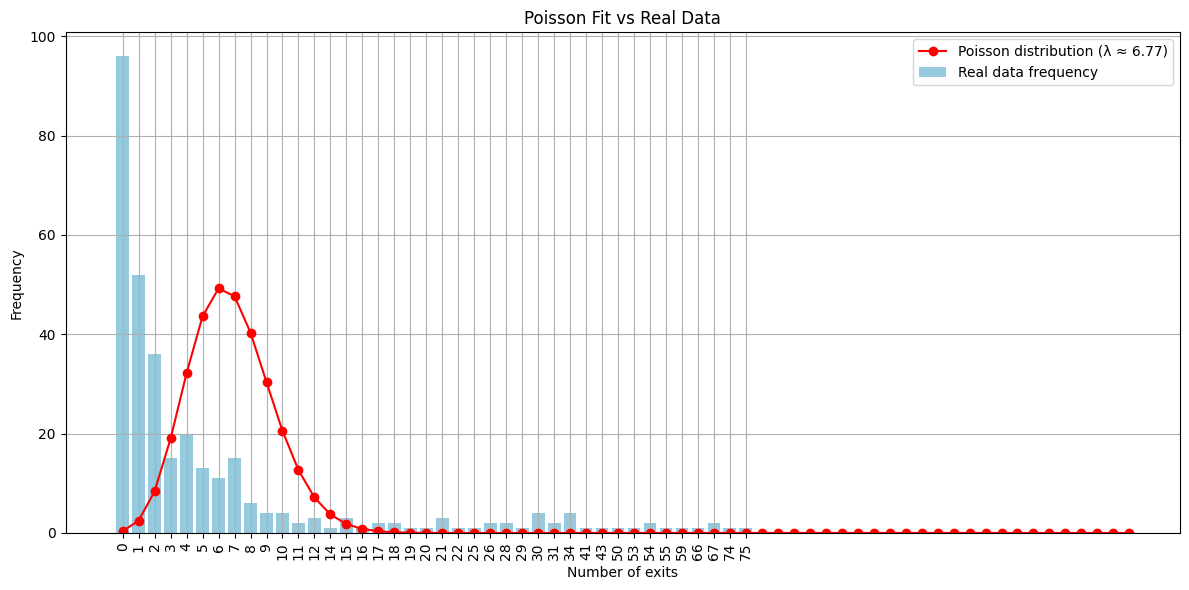

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=frequency.index, y=frequency.values, color="skyblue", label="Real data frequency")
plt.plot(x_vals, poisson_probs, 'r-o', label=f"Poisson distribution (λ ≈ {exits_mean:.2f})")
plt.xlabel("Number of exits")
plt.ylabel("Frequency")
plt.title("Poisson Fit vs Real Data")
plt.legend()
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
p_exits = exits_mean / exits_variance
r_exits = exits_mean**2 / (exits_variance - exits_mean)

In [ ]:
nb_probs_exits = nbinom.pmf(x_vals, r, p) * len(entries)

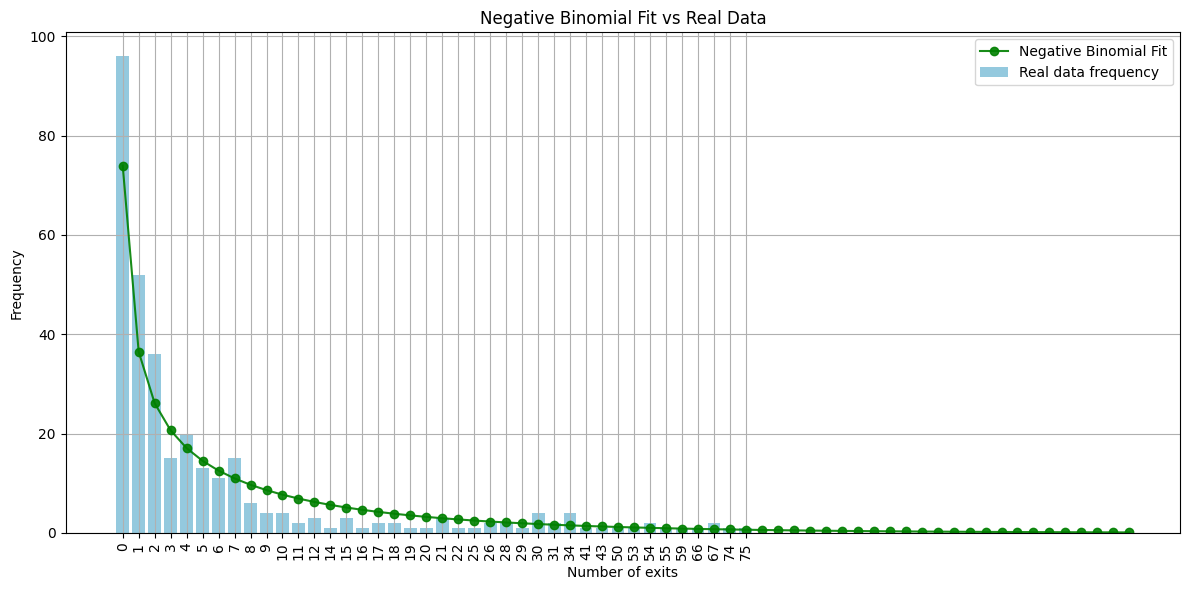

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=frequency.index, y=frequency.values, color="skyblue", label="Real data frequency")
plt.plot(x_vals, nb_probs, 'g-o', label="Negative Binomial Fit", alpha=0.9)
plt.xlabel("Number of exits")
plt.ylabel("Frequency")
plt.title("Negative Binomial Fit vs Real Data")
plt.legend()
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()